In [21]:
!mkdir -p ~/.kaggle
!echo KGAT_aade15e49b0b38b5b0297eaa2b4690b3 > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

# **DATASET 1: E-COMMERCE**

In [8]:
import pandas as pd
import glob
import os

print("\nKẾT QUẢ EDA DATASET 1: E-COMMERCE")
csv_files_potential = glob.glob('**/*.csv', recursive=True)

if csv_files_potential:
    csv_file_path = csv_files_potential[0]
    dataset_root = os.path.dirname(csv_file_path) or '.'

    image_files = glob.glob(os.path.join(dataset_root, '**/*.jpg'), recursive=True) + \
                  glob.glob(os.path.join(dataset_root, '**/*.png'), recursive=True)
    print(f"Tổng số lượng ảnh tìm thấy: {len(image_files)} ảnh")

    df1 = pd.read_csv(csv_file_path, on_bad_lines='skip')
    print(f"Tổng số mẫu/dòng: {df1.shape[0]}")
    print(f"Các trường dữ liệu/cột: {df1.shape[1]}")
    print(f"Tổng giá trị thiếu trên toàn bộ DataFrame: {df1.isnull().sum().sum()}")

    print("\nDữ liệu mẫu (2 dòng đầu):")
    display(df1.head(2))
else:
    print("Không tìm thấy file CSV.")


KẾT QUẢ EDA DATASET 1: E-COMMERCE
Tổng số lượng ảnh tìm thấy: 88882 ảnh
Tổng số mẫu/dòng: 44424
Các trường dữ liệu/cột: 10
Tổng giá trị thiếu trên toàn bộ DataFrame: 361

Dữ liệu mẫu (2 dòng đầu):


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans


# **DATASET 2: FASHION PRODUCT IMAGES DATASET**


KẾT QUẢ EDA DATASET 2: FASHION PRODUCT IMAGES
Tổng số mẫu (dòng): 44424
Tổng số trường dữ liệu (cột): 10
Tổng giá trị thiếu trên toàn bộ DataFrame: 361

Ảnh mẫu:


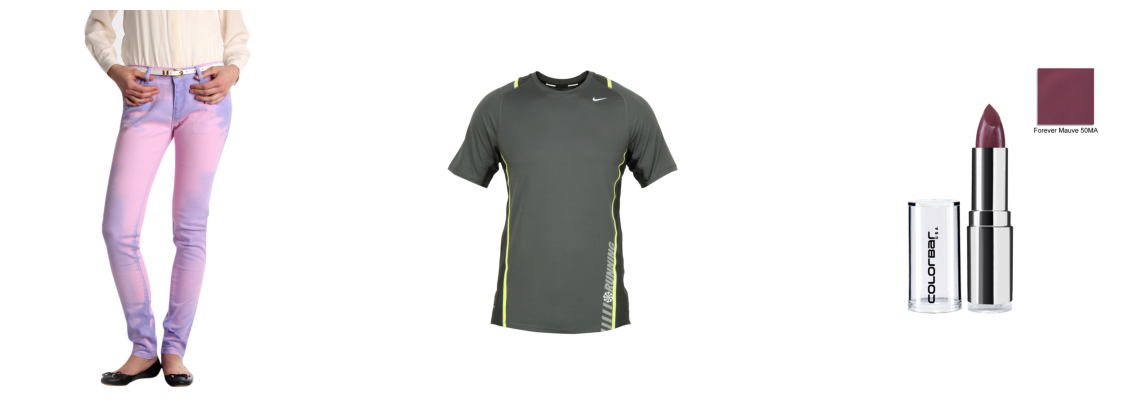

In [9]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

print("\nKẾT QUẢ EDA DATASET 2: FASHION PRODUCT IMAGES")
fashion_csv_paths = glob.glob('/content/**/styles.csv', recursive=True)

if fashion_csv_paths:
    df2 = pd.read_csv(fashion_csv_paths[0], on_bad_lines='skip')
    print(f"Tổng số mẫu (dòng): {df2.shape[0]}")
    print(f"Tổng số trường dữ liệu (cột): {df2.shape[1]}")
    print(f"Tổng giá trị thiếu trên toàn bộ DataFrame: {df2.isnull().sum().sum()}")

    dataset_root = os.path.dirname(fashion_csv_paths[0])
    img_folder = os.path.join(dataset_root, 'images')

    if os.path.exists(img_folder):
        sample_imgs = os.listdir(img_folder)[:3]
        print("\nẢnh mẫu:")
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))
        for i, img_name in enumerate(sample_imgs):
            img_path = os.path.join(img_folder, img_name)
            ax[i].imshow(mpimg.imread(img_path))
            ax[i].axis('off')
        plt.show()
else:
    print("Không tìm thấy file styles.csv.")

# **DATASET 3: FASHION IQ**

In [17]:
import pandas as pd
import glob
import os
import json

print("\nKẾT QUẢ EDA DATASET 3: FASHION IQ")
# Quét rộng colab
json_files = glob.glob('**/*.json', recursive=True)
# Lọc ra file json của FashionIQ
target_jsons = [f for f in json_files if 'cap' in f]

if target_jsons:
    with open(target_jsons[0], 'r') as f:
        data = json.load(f)

    print(f"Tổng số lượng Triplet (Ảnh gốc + Text thay đổi + Ảnh đích): {len(data)} mẫu")

    print("\nCấu trúc của 1 Triplet mẫu:")
    print(json.dumps(data[0], indent=4, ensure_ascii=False))

    df3 = pd.DataFrame(data)
    print(f"Tổng giá trị thiếu trên toàn bộ DataFrame: {df3.isnull().sum().sum()}")
    print("\nDữ liệu mẫu (3 dòng đầu):")
    display(df3.head(3))
else:
    print("Không tìm thấy file JSON.")


KẾT QUẢ EDA DATASET 3: FASHION IQ
Tổng số lượng Triplet (Ảnh gốc + Text thay đổi + Ảnh đích): 2024 mẫu

Cấu trúc của 1 Triplet mẫu:
{
    "candidate": "B007E66YTO",
    "captions": [
        " yello and more flowing",
        "short and black"
    ]
}
Tổng giá trị thiếu trên toàn bộ DataFrame: 0

Dữ liệu mẫu (3 dòng đầu):


,candidate,captions
0,B007E66YTO,"[ yello and more flowing, short and black]"
1,B007CPAGDW,[sleeveless satin dress gold and black with or...
2,B0020MKZ7O,"[is solid black with spaghetti straps, has sle..."


# **DATASET 4: DEEPFASHION**

In [26]:
!mkdir -p /content/dataset4
!kaggle datasets download -d silverstone1903/deep-fashion-multimodal -p /content/dataset4 --unzip

import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

print("\nKẾT QUẢ EDA DATASET 4: DEEPFASHION")

image_files = glob.glob('/content/dataset4/**/*.jpg', recursive=True) + glob.glob('/content/dataset4/**/*.png', recursive=True)
print(f"Tổng số lượng ảnh tìm thấy: {len(image_files)} ảnh")

all_meta_files = glob.glob('/content/dataset4/**/*.csv', recursive=True) + \
                 glob.glob('/content/dataset4/**/*.json', recursive=True) + \
                 glob.glob('/content/dataset4/**/*.txt', recursive=True)

print("\nDanh sách các file metadata thực tế có trong bộ dữ liệu này:")
for f in all_meta_files:
    print(f" - {f}")

if all_meta_files:
    target_file = all_meta_files[0]
    print(f"\nĐang tiến hành đọc file: {target_file}")
    try:
        if target_file.endswith('.csv') or target_file.endswith('.txt'):
            df4 = pd.read_csv(target_file, sep=None, engine='python', on_bad_lines='skip')
        else:
            df4 = pd.read_json(target_file)

        print(f"Tổng số mẫu (dòng): {df4.shape[0]}")
        print(f"Các trường dữ liệu (cột): {df4.shape[1]}")
        print("\nVấn đề chất lượng (Số lượng ô rỗng):")
        print(df4.isnull().sum())
        print(f"Tổng giá trị thiếu trên toàn bộ DataFrame df4: {df4.isnull().sum().sum()}")
        display(df4.head(3))
    except Exception as e:
        print(f"Lỗi khi cố gắng đọc file {target_file}: {e}")
else:
    print("\nKhông tìm thấy file metadata.")

Dataset URL: https://www.kaggle.com/datasets/silverstone1903/deep-fashion-multimodal
License(s): CC-BY-NC-SA-4.0
100% 1.89G/1.89G [00:16<00:00, 124MB/s]


KẾT QUẢ EDA DATASET 4: DEEPFASHION
Tổng số lượng ảnh tìm thấy: 12278 ảnh

Danh sách các file metadata thực tế có trong bộ dữ liệu này:
 - /content/dataset4/labels_front.csv

Đang tiến hành đọc file: /content/dataset4/labels_front.csv
Tổng số mẫu (dòng): 12278
Các trường dữ liệu (cột): 7

Vấn đề chất lượng (Số lượng ô rỗng):
image_id        0
caption         0
path            0
gender          0
product_type    0
product_id      0
image_type      0
dtype: int64
Tổng giá trị thiếu trên toàn bộ DataFrame df4: 0


,image_id,caption,path,gender,product_type,product_id,image_type
0,MEN-Denim-id_00000089-28_1_front,This gentleman is wearing a medium-sleeve shir...,MEN-Denim-id_00000089-28_1_front.jpg,MEN,Denim,id_00000089,front
1,MEN-Denim-id_00000265-01_1_front,This person is wearing a short-sleeve shirt wi...,MEN-Denim-id_00000265-01_1_front.jpg,MEN,Denim,id_00000265,front
2,MEN-Denim-id_00000313-01_1_front,The gentleman is wearing a short-sleeve T-shir...,MEN-Denim-id_00000313-01_1_front.jpg,MEN,Denim,id_00000313,front


# **DATASET 5: H&M BẢN MIRROR**

In [27]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

!kaggle datasets download -d derrickmwiti/hm-personalized-fashion-recommendations --unzip

print("\nKẾT QUẢ EDA DATASET 5: H&M BẢN MIRROR")

hm_parquet_candidates = glob.glob('/content/**/articles.parquet', recursive=True)

df_hm = None
if hm_parquet_candidates:
    hm_parquet_path = hm_parquet_candidates[0]
    dataset_root = os.path.dirname(hm_parquet_path)

    print(f'\nĐã tìm thấy file metadata tại: {hm_parquet_path}')
    print(f'Thư mục gốc của Dataset 5: {dataset_root}')

    df_hm = pd.read_parquet(hm_parquet_path)

    print(f'\nTổng số mẫu (dòng): {df_hm.shape[0]}')
    print(f'Các trường dữ liệu (cột): {df_hm.shape[1]}')
    print('\nChi tiết các trường:')
    print(df_hm.info())
    print('\nVấn đề chất lượng (Dữ liệu rỗng):')
    print(df_hm.isnull().sum())
    print(f'Tổng giá trị thiếu trên toàn bộ DataFrame df_hm: {df_hm.isnull().sum().sum()}')
    display(df_hm.head(2))

else:
    print(f"\nKhông tìm thấy file articles.parquet trong bất kỳ thư mục nào trong '/content/'. Vui lòng kiểm tra tên file hoặc dataset đã được giải nén thành công chưa.")

Dataset URL: https://www.kaggle.com/datasets/derrickmwiti/hm-personalized-fashion-recommendations
License(s): unknown
100% 709M/709M [00:10<00:00, 72.3MB/s]


KẾT QUẢ EDA DATASET 5: H&M BẢN MIRROR

Đã tìm thấy file metadata tại: /content/articles.parquet
Thư mục gốc của Dataset 5: /content

Tổng số mẫu (dòng): 105542
Các trường dữ liệu (cột): 25

Chi tiết các trường:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105542 entries, 0 to 105541
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   article_id                    105542 non-null  int64 
 1   product_code                  105542 non-null  int64 
 2   prod_name                     105542 non-null  object
 3   product_type_no               105542 non-null  int64 
 4   product_type_name             105542 non-null  object
 5   product_group_name            105542 non-null  object
 6   graphical_appearance_no       105542 non-n

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
